In [1]:
import os
import sys
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_path = r"D:\DFUC_Project"

if project_path not in sys.path:
    sys.path.append(project_path)

In [3]:
from src.preprocessing import (
    resize_image,
    normalize_image,
    apply_clahe,
    apply_bilateral_filter,
    resize_bounding_boxes,
    draw_boxes
)

In [4]:
annotation_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\groundtruth.csv"

train_image_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\images"

In [5]:
from src.dataset import (
    load_annotations,
    prepare_training_sample
)

In [6]:
annotations = load_annotations(annotation_path)

image, boxes = prepare_training_sample(
    "100001.jpg",
    train_image_path,
    annotations
)

print(image.shape)

boxes

(256, 256, 3)


,filename,xmin,ymin,xmax,ymax
0,100001,108,99,121,127
1,100001,14,93,49,136


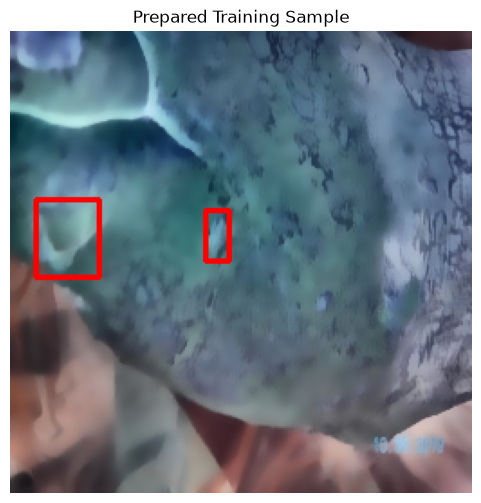

In [7]:
from src.preprocessing import draw_boxes

output = draw_boxes(
    (image * 255).astype("uint8"),
    boxes
)

plt.figure(figsize=(6, 6))
plt.imshow(output)
plt.axis("off")
plt.title("Prepared Training Sample")
plt.show()

In [8]:
import torch

from src.targets import create_detection_target

target = create_detection_target(boxes)

print("Target shape:", target.shape)
print("Ulcer cells:", torch.sum(target[0]).item())

Target shape: torch.Size([5, 32, 32])
Ulcer cells: 2.0


In [9]:
from src.dataset import DFUCDataset

dataset = DFUCDataset(
    train_image_path,
    annotations
)

image, target = dataset[0]

print("Dataset size:", len(dataset))
print("Image shape:", image.shape)
print("Target shape:", target.shape)
print("Ulcer cells:", target[0].sum().item())

Dataset size: 2000
Image shape: torch.Size([3, 256, 256])
Target shape: torch.Size([5, 32, 32])
Ulcer cells: 2.0
